# DSCI 503 - Homework 04
### Ben Miller

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Problem 1: Sample Mean and Variance

In [5]:
x = np.array([10, 16, 26, 12, 17, 22, 14, 12, 21, 16])
n = len(x)
mean = np.sum(x) / n

diff = x - mean

# sample variance
var = (np.sum(diff**2) / (n - 1))

print("Sample Mean:    ", mean)
print("Sample Variance:", var)

Sample Mean:     16.6
Sample Variance: 25.6


In [6]:
mean_np = np.mean(x)
var_np = np.var(x, ddof=1)

print("Sample Mean:    ", mean_np)
print("Sample Variance:", var_np)

Sample Mean:     16.6
Sample Variance: 25.6


## Problem 2: Scoring a Regression Model

In [7]:
def find_sse(true_y, pred_y):
    diff = true_y - pred_y
    sse = np.sum(diff**2)
    return sse

In [8]:
true_y = np.array([22.1, 17.9, 16.5, 14.3, 19.8, 23.7, 22.0, 18.4, 25.7, 19.2])
pred_1 = np.array([21.4, 16.7, 17.9, 12.1, 22.1, 25.1, 21.7, 19.3, 23.4, 19.9])
pred_2 = np.array([20.7, 18.1, 16.9, 13.6, 21.9, 24.8, 20.3, 21.1, 24.8, 18.4])

sse_1 = find_sse(true_y, pred_1)
sse_2 = find_sse(true_y, pred_2)

print("Model 1 SSE:", round(sse_1, 2))
print("Model 2 SSE:", round(sse_2, 2))

Model 1 SSE: 22.66
Model 2 SSE: 19.9


## Problem 3: Scoring a Classification Model

In [9]:
def find_accuracy(true_y, pred_y):
    correct = np.sum(true_y == pred_y)
    accuracy = correct / len(true_y)
    return accuracy

In [10]:
true_diag = np.array(['P', 'P', 'N', 'N', 'P', 'N', 'N', 'N', 'P', 'N', 
                      'N', 'N', 'N', 'P', 'P', 'N', 'N','N', 'N', 'N'])
pred_diag = np.array(['N', 'P', 'N', 'P', 'P', 'N', 'P', 'N', 'P', 'N', 
                      'N', 'N', 'P', 'P', 'P', 'N', 'N','N', 'P', 'N'])

accuracy = find_accuracy(true_diag, pred_diag)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.75


In [11]:
true_labels = np.array(['dog', 'dog', 'cat', 'dog', 'cat', 'cat', 'cat', 
                        'dog', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 
                        'dog', 'dog', 'dog', 'cat', 'cat', 'cat', 'dog', 
                        'dog', 'cat', 'cat'])
pred_labels = np.array(['dog', 'dog', 'cat', 'dog', 'cat', 'dog', 'cat', 
                         'dog', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 
                         'cat', 'dog', 'dog', 'cat', 'dog', 'cat', 'dog', 
                         'dog', 'cat', 'cat'])

accuracy = find_accuracy(true_labels, pred_labels)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.875


## Problem 4: Classification Report

In [12]:
def classification_report(true_y, pred_y):
    classes = np.unique(true_y)
    negative = classes[0]
    positive = classes[1] 
    
    
    accuracy = find_accuracy(true_y, pred_y)

    tp = np.sum((true_y == positive) & (pred_y == positive))
    fp = np.sum((true_y == negative) & (pred_y == positive))
    tn = np.sum((true_y == negative) & (pred_y == negative))
    fn = np.sum((true_y == positive) & (pred_y == negative))

    positive_precision = tp / (tp + fp)
    positive_recall = tp / (tp + fn)
    negative_precision = tn / (tn + fn)
    negative_recall = tn / (tn + fp)
    
    print("Positive Class:    ", positive)
    print("Negative Class:    ", negative, "\n")
    print("Accuracy:          ", round(accuracy, 4))
    print("Positive Precision:", round(positive_precision, 4))
    print("Positive Recall:   ", round(positive_recall, 4))
    print("Negative Precision:", round(negative_precision, 4))
    print("Negative Recall:   ", round(negative_recall, 4))

In [13]:
classification_report(true_diag, pred_diag)

Positive Class:     P
Negative Class:     N 

Accuracy:           0.75
Positive Precision: 0.5556
Positive Recall:    0.8333
Negative Precision: 0.9091
Negative Recall:    0.7143


In [14]:
classification_report(true_labels, pred_labels)

Positive Class:     dog
Negative Class:     cat 

Accuracy:           0.875
Positive Precision: 0.8333
Positive Recall:    0.9091
Negative Precision: 0.9167
Negative Recall:    0.8462


## Problem 5: Transformation of Random Variables

In [15]:
np.random.seed(1)
X = np.random.normal(loc=0, scale = 0.4, size=25000)
Y = np.exp(X)

print("Sample Mean of X:    ", round(np.mean(X), 4))
print("Sample Std Dev of X: ", round(np.std(X, ddof=1), 4))
print("Sample Mean of Y:    ", round(np.mean(Y), 4))
print("Sample Std Dev of Y: ", round(np.std(Y, ddof=1), 4))

Sample Mean of X:     0.0025
Sample Std Dev of X:  0.4002
Sample Mean of Y:     1.0862
Sample Std Dev of Y:  0.4537


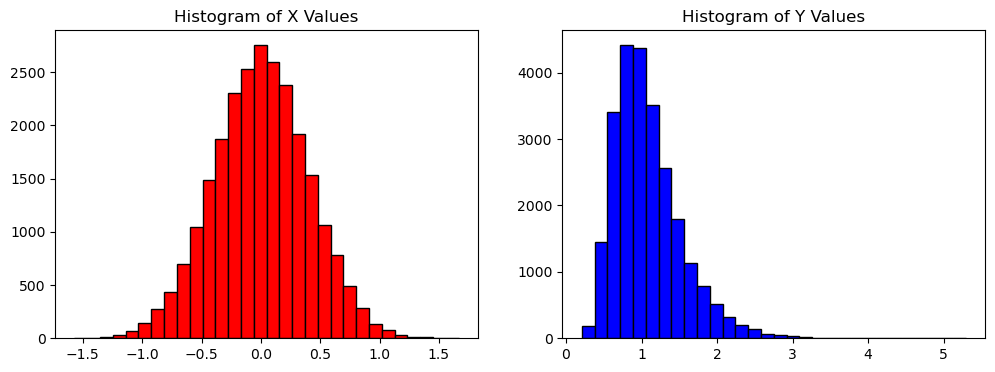

In [16]:
plt.figure(figsize=[12,4])

plt.subplot(1, 2, 1)
plt.hist(X, edgecolor="black", color="red", bins=30)
plt.title("Histogram of X Values")

plt.subplot(1, 2, 2)
plt.hist(Y, edgecolor="black", color="blue", bins=30)
plt.title("Histogram of Y Values")

plt.show()

In [17]:
print("Probability that Y is less than 0.5:", round(np.mean(Y < 0.5), 4))
print("probability that Y is less than 1.0:", round(np.mean(Y < 1.0), 4))
print("Probability that Y is less than 2.0:", round(np.mean(Y < 2.0), 4))

Probability that Y is less than 0.5: 0.041
probability that Y is less than 1.0: 0.4969
Probability that Y is less than 2.0: 0.9574


## Problem 6: Stochastic Linear Relationships

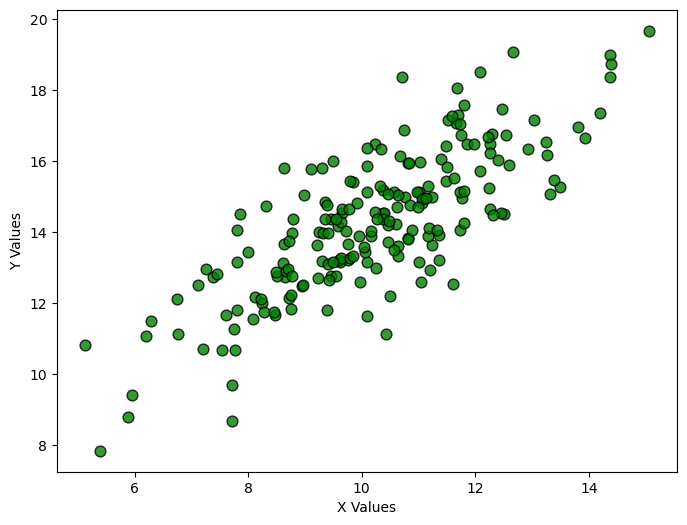

In [18]:
np.random.seed(1)
x_vals = np.random.normal(loc=10, scale=2, size=200) # mean of 10, std dev of 2, 200 values
errors = np.random.normal(loc=0, scale = 1.2, size=200) # mean of 0, std dev of 1.2, 200 values
Y = 5.1 + (0.9 * x_vals) + errors

plt.figure(figsize=[8, 6])
plt.scatter(x_vals, Y, s=60, alpha=0.8, color="green", edgecolor="black")
plt.xlabel("X Values")
plt.ylabel("Y Values")

plt.show()

In [19]:
diff_x = x_vals - np.mean(x_vals)
diff_y = Y - np.mean(Y)
r_top = np.sum(diff_x * diff_y)
r_bottom = math.sqrt(np.sum(diff_x**2) * np.sum(diff_y**2))
r = r_top / r_bottom
print("Correlation between X and Y:", round(r, 4))

Correlation between X and Y: 0.7861


## Problem 7: Relationship between Life Expectancy and Per Capita GDP

In [20]:
import pandas as pd
df = pd.read_csv('gapminder_data.txt', sep='\t')
country = df.country.values
year = df.year.values
continent = df.continent.values
population = df.population.values
life_exp = df.life_exp.values
pcgdp = df.gdp_per_cap.values
gini = df.gini.values
df = None

In [21]:
continent_list = ['africa', 'americas', 'asia', 'europe']
color_list = ['red', 'blue', 'green', 'orange']

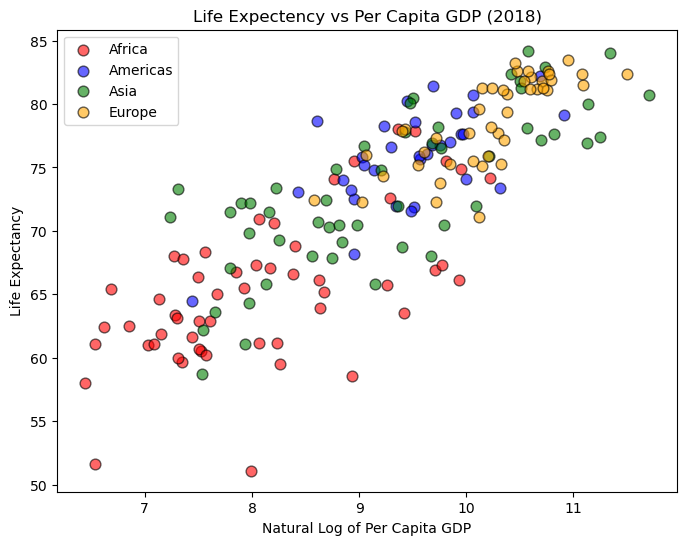

In [22]:
plt.figure(figsize=[8, 6])
for i in range(len(continent_list)): 
    # Boolean mask for filtering by current continent and year 2018
    sel = (continent == continent_list[i]) & (year == 2018) 
    
    x = np.log(pcgdp[sel]) # natural log of per capita gdp
    y = life_exp[sel] # life expectancy of the selected countries
    plt.scatter(x, y, s=60, alpha=0.6, color=color_list[i], 
                edgecolor="black", label=continent_list[i].title())
    
plt.xlabel("Natural Log of Per Capita GDP")
plt.ylabel("Life Expectancy")
plt.title("Life Expectency vs Per Capita GDP (2018)")
plt.legend()
plt.show()

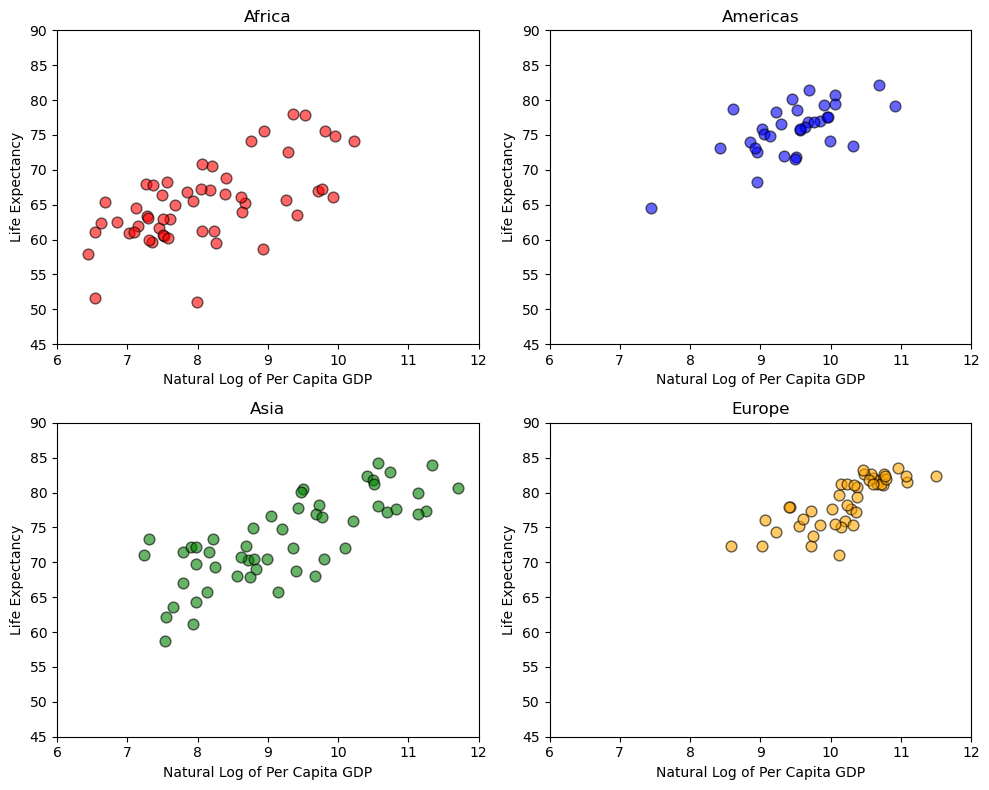

In [23]:
plt.figure(figsize=[10, 8])
for i in range(len(continent_list)): 
    # Boolean mask for filtering by current continent and year 2018
    sel = (continent == continent_list[i]) & (year == 2018) 
    
    x = np.log(pcgdp[sel]) # natural log of per capita gdp
    y = life_exp[sel] # life expectancy of the selected countries

    plt.subplot(2, 2, i + 1)
    plt.scatter(x, y, s=60, alpha=0.6, color=color_list[i], 
                edgecolor="black")
    plt.xlim([6, 12])
    plt.ylim([45, 90])
    plt.xlabel("Natural Log of Per Capita GDP")
    plt.ylabel("Life Expectancy")
    plt.title(continent_list[i].title())

plt.tight_layout()
plt.show()

## Problem 8: Trends by Country

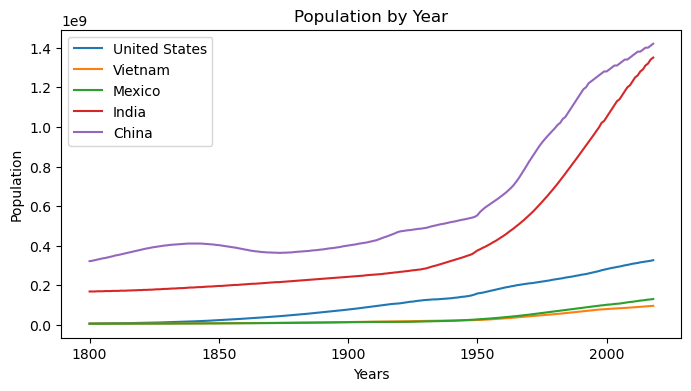

In [24]:
countries = ["United States", "Vietnam", "Mexico", "India", "China"]

plt.figure(figsize=[8, 4])
for i in range(len(countries)):
    mask = (country == countries[i])
    country_pop = population[mask] 
    country_year = year[mask]

    plt.plot(country_year, country_pop, label=countries[i])

plt.xlabel("Years")
plt.ylabel("Population")
plt.title("Population by Year")
plt.legend()
plt.show()

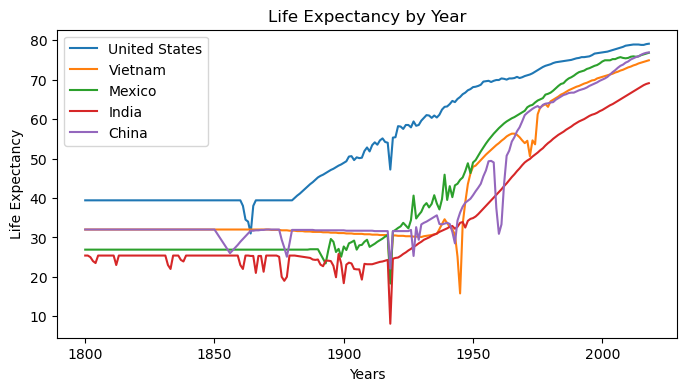

In [25]:
plt.figure(figsize=[8, 4])
for i in range(len(countries)):
    mask = (country == countries[i])
    country_life_exp = life_exp[mask] 
    country_year = year[mask]

    plt.plot(country_year, country_life_exp, label=countries[i])

plt.xlabel("Years")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy by Year")
plt.legend()
plt.show()